# Gradient, Directional Derivative, and the Dot Product

This notebook visualizes the relationship between the **gradient** $\nabla f(\mathbf{x})$ of a scalar field $f(x,y)$ and the **directional derivative**

$$
D_{\mathbf{u}} f(\mathbf{x}) = \nabla f(\mathbf{x}) \cdot \mathbf{u}, \qquad \|\mathbf{u}\| = 1.
$$

Drag the sliders to move the point $\mathbf{x} = (x_0, y_0)$ around the plane and rotate the unit vector $\mathbf{u}$ using the angle slider. The right-hand panel plots $D_{\mathbf{u}}f$ as a function of the angle of $\mathbf{u}$:

- **Maximum** ($D_\mathbf{u}f = \|\nabla f\|$) when $\mathbf{u}$ is aligned with $\nabla f$.
- **Zero** when $\mathbf{u} \perp \nabla f$ (i.e. $\mathbf{u}$ is tangent to the level curve through $\mathbf{x}$).
- **Minimum** ($D_\mathbf{u}f = -\|\nabla f\|$) when $\mathbf{u}$ points opposite to $\nabla f$.

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interactive_output, HBox, VBox, FloatSlider
from IPython.display import display

#increase font sizes
plt.rcParams.update({'font.size': 12})

## Define a "complicated" scalar field $f(x,y)$

We use `sympy` to define $f$ symbolically and differentiate it exactly, then compile the result to fast numerical functions with `lambdify`.

In [2]:
x, y = sp.symbols("x y", real=True)

# A deliberately "busy" scalar field: a mix of oscillations, a saddle term,
# and a coupling term, so the level sets and gradient field are non-trivial.
f_expr = (
    sp.sin(x) * sp.cos(y)
    + sp.Rational(1, 3) * sp.sin(2 * x - y)
    + sp.Rational(1, 5) * (x**2 - y**2) / 4
    + sp.Rational(1, 10) * sp.cos(x * y)
)

grad_expr = sp.Matrix([sp.diff(f_expr, x), sp.diff(f_expr, y)])

print("f(x, y)  =", f_expr)
print("∇f(x, y) =", grad_expr.T)

f_num = sp.lambdify((x, y), f_expr, "numpy")
grad_num = sp.lambdify((x, y), grad_expr, "numpy")


def gradient(x0, y0):
    """Return the gradient of f at (x0, y0) as a flat numpy array."""
    g = np.array(grad_num(x0, y0), dtype=float).reshape(-1)
    return g

f(x, y)  = x**2/20 - y**2/20 + sin(x)*cos(y) + sin(2*x - y)/3 + cos(x*y)/10
∇f(x, y) = Matrix([[x/10 - y*sin(x*y)/10 + cos(x)*cos(y) + 2*cos(2*x - y)/3, -x*sin(x*y)/10 - y/10 - sin(x)*sin(y) - cos(2*x - y)/3]])


## Interactive visualization

In [5]:
DOMAIN = 3.2  # half-width of the plotted domain around the origin
GRID_N = 300
ARROW_SCALE = 1.0  # visual length scale for the u and gradient arrows

xs = np.linspace(-DOMAIN, DOMAIN, GRID_N)
ys = np.linspace(-DOMAIN, DOMAIN, GRID_N)
Xg, Yg = np.meshgrid(xs, ys)
Zg = f_num(Xg, Yg)

# A handful of reference directions, drawn faintly, in addition to the
# actively rotating u vector -- these are just fixed compass directions.
reference_angles_deg = [0, 45, 90, 135, 180, 225, 270, 315]


def draw(x0, y0, theta_deg):
    plt.close("all")  # guard against any stray figures from previous calls
    theta = np.deg2rad(theta_deg)
    u = np.array([np.cos(theta), np.sin(theta)])

    g = gradient(x0, y0)
    g_norm = np.linalg.norm(g)
    g_hat = g / g_norm if g_norm > 1e-12 else np.zeros(2)

    directional_deriv = float(g @ u)

    fig, (ax_map, ax_curve) = plt.subplots(
        1, 2, figsize=(11, 5), gridspec_kw={"width_ratios": [1.2, 1]}
    )

    # --- Left panel: contour map with point, gradient, and direction vectors ---
    contours = ax_map.contour(Xg, Yg, Zg, levels=25, cmap="viridis", linewidths=0.8)
    ax_map.clabel(contours, inline=True, fontsize=7, fmt="%.2f")
    ax_map.plot(x0, y0, "o", color="black", ms=7, zorder=5)
    ax_map.annotate(
        r"$\mathbf{x}$", (x0, y0), textcoords="offset points", xytext=(8, 8), fontsize=12
    )

    # faint reference directions (unit length)
    for ang in reference_angles_deg:
        r = np.deg2rad(ang)
        ax_map.arrow(
            x0, y0, np.cos(r) * ARROW_SCALE, np.sin(r) * ARROW_SCALE,
            width=0.005, head_width=0.06, length_includes_head=True,
            color="gray", alpha=0.35, zorder=3,
        )

    # gradient vector (red)
    if g_norm > 1e-12:
        ax_map.arrow(
            x0, y0, g[0] * ARROW_SCALE, g[1] * ARROW_SCALE,
            width=0.02, head_width=0.14, length_includes_head=True,
            color="crimson", zorder=6, label=r"$\nabla f$",
        )
        ax_map.annotate(
            r"$\nabla f$", (x0 + g[0] * ARROW_SCALE, y0 + g[1] * ARROW_SCALE),
            textcoords="offset points", xytext=(6, 6), color="crimson", fontsize=12,
        )

    # rotating unit vector u (blue)
    ax_map.arrow(
        x0, y0, u[0] * ARROW_SCALE, u[1] * ARROW_SCALE,
        width=0.02, head_width=0.14, length_includes_head=True,
        color="royalblue", zorder=7, label=r"$\mathbf{u}$",
    )
    ax_map.annotate(
        r"$\mathbf{u}$", (x0 + u[0] * ARROW_SCALE, y0 + u[1] * ARROW_SCALE),
        textcoords="offset points", xytext=(6, -12), color="royalblue", fontsize=12,
    )

    ax_map.set_xlim(-DOMAIN, DOMAIN)
    ax_map.set_ylim(-DOMAIN, DOMAIN)
    ax_map.set_aspect("equal")
    ax_map.set_xlabel("$x$")
    ax_map.set_ylabel("$y$")
    ax_map.set_title("Level curves of $f$, gradient, and direction $\\mathbf{u}$")

    # --- Right panel: D_u f(x) as a function of the angle of u ---
    angles = np.linspace(0, 360, 361)
    rad = np.deg2rad(angles)
    curve = g[0] * np.cos(rad) + g[1] * np.sin(rad)

    ax_curve.plot(angles, curve, color="royalblue", lw=2)
    ax_curve.axhline(0, color="gray", lw=1, ls="--")
    ax_curve.axhline(g_norm, color="crimson", lw=1, ls=":", label=r"$+\|\nabla f\|$ (max)")
    ax_curve.axhline(-g_norm, color="crimson", lw=1, ls=":", label=r"$-\|\nabla f\|$ (min)")
    ax_curve.plot([theta_deg], [directional_deriv], "o", color="black", ms=9, zorder=5)
    ax_curve.set_xlim(0, 360)
    ax_curve.set_xticks([0, 90, 180, 270, 360])
    ax_curve.set_xlabel(r"angle of $\mathbf{u}$ (degrees)")
    ax_curve.set_ylabel(r"$D_\mathbf{u} f(\mathbf{x}) = \nabla f \cdot \mathbf{u}$")
    ax_curve.set_title("Directional derivative vs. angle of $\\mathbf{u}$")
    ax_curve.legend(loc="upper right", fontsize=8)

    fig.suptitle(
        rf"$\|\nabla f\| = {g_norm:.3f}$,   "
        rf"$D_\mathbf{{u}} f = \nabla f \cdot \mathbf{{u}} = {directional_deriv:.3f}$",
        fontsize=12,
    )
    fig.tight_layout()
    plt.show()
    plt.close(fig)

In [6]:
x_slider = FloatSlider(value=0.6, min=-DOMAIN, max=DOMAIN, step=0.05, description="x₀")
y_slider = FloatSlider(value=-0.4, min=-DOMAIN, max=DOMAIN, step=0.05, description="y₀")
theta_slider = FloatSlider(value=0, min=0, max=360, step=1, description="angle of u (°)")

ui = VBox([
    HBox([x_slider, y_slider]),
    theta_slider,
])

out = interactive_output(
    draw, {"x0": x_slider, "y0": y_slider, "theta_deg": theta_slider}
)

display(VBox([ui, out]))

## Takeaways

- The **gradient** $\nabla f(\mathbf{x})$ (red) always points in the direction of steepest ascent, perpendicular to the level curve through $\mathbf{x}$.
- The **directional derivative** $D_\mathbf{u}f = \nabla f \cdot \mathbf{u} = \|\nabla f\| \cos\phi$, where $\phi$ is the angle between $\mathbf{u}$ and $\nabla f$.
- As $\mathbf{u}$ (blue) sweeps around the point, the curve on the right traces out exactly this cosine relationship:
  - Maximum when $\mathbf{u} \parallel \nabla f$ (arrows aligned),
  - Zero when $\mathbf{u} \perp \nabla f$ (arrow tangent to the level curve),
  - Minimum when $\mathbf{u}$ points opposite to $\nabla f$.

## Gradient flow: following $-\nabla f$ to a critical point

Instead of sweeping a direction $\mathbf{u}$ at a fixed point, we now let the point itself move. The **gradient flow** (steepest-descent flow) is the solution of the ODE

$$
\dot{\mathbf{x}}(t) = -\nabla f(\mathbf{x}(t)), \qquad \mathbf{x}(0) = \mathbf{x}_0,
$$

which always moves in the direction of steepest decrease of $f$. Pick a starting point $\mathbf{x}_0$ with the sliders, then press **START** to integrate the flow until $\|\nabla f\|$ drops below a small threshold (i.e. until a critical point is reached).


In [21]:
# define gradient flow ODE:
def odefun(t, z):
    x, y = z
    g = gradient(x, y)
    return -g

# select initial point 
x0, y0 = 0.0, 0.0  # example initial point




In [33]:
# integrate ODE
from scipy.integrate import solve_ivp

t_span = (0, 20)  # time span
z0 = [x0, y0]
sol = solve_ivp(odefun, t_span, z0, method="RK45", dense_output=True)

x_star = sol.y[:, -1]
print("Optimal point:", x_star)

Optimal point: [-1.13483003 -0.2261952 ]


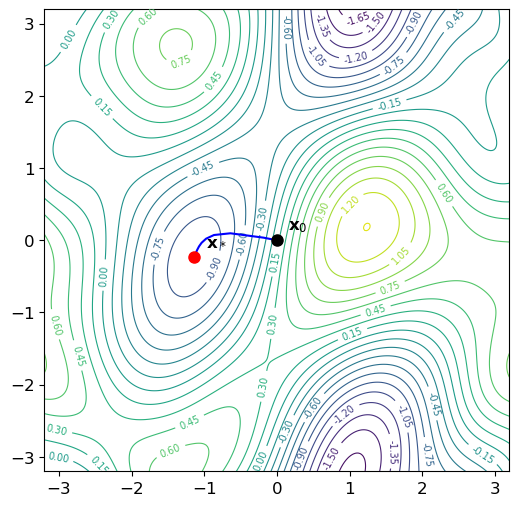

In [35]:
# Make contour plot and superimpose solution
fig, ax = plt.subplots(figsize=(6, 6))
contours = ax.contour(Xg, Yg, Zg, levels=25, cmap="viridis", linewidths=0.8)
ax.clabel(contours, inline=True, fontsize=7, fmt="%.2f")

ax.plot(sol.y[0], sol.y[1], "-", color="blue", lw=1.5, zorder=5, label="trajectory")
ax.plot(x0, y0, "o", color="black", ms=8, zorder=6, label="start")
ax.annotate(
    r"$\mathbf{x}_0$", (x0, y0), textcoords="offset points", xytext=(8, 8), fontsize=12
)
ax.plot(x_star[0], x_star[1], "o", color="red", ms=8, zorder=6, label="optimal")
ax.annotate(
    r"$\mathbf{x}_*$", (x_star[0], x_star[1]), textcoords="offset points", xytext=(8, 8), fontsize=12
)

plt.savefig("gradient_flow.svg", bbox_inches="tight")

plt.show()
